# Poisson Distribution: "How many events in a fixed interval?"

The **Poisson distribution** models the **number of times an event occurs in a fixed interval of time or space**, when events happen **independently** and at a **constant average rate**.

Typical examples: calls per hour, patients arriving per night, emails per day, typos per page, accidents per week, website hits per second, radioactive decays per minute.

**Contents**
1. Setup
2. The idea, conditions and formula (PMF)
3. Building intuition: from Binomial to Poisson
4. Mean and variance (with proofs): the equidispersion property
5. Shape of the distribution
6. Cumulative probabilities
7. Changing the interval: scaling λ
8. Sum of independent Poissons; splitting (thinning)
9. Poisson process & link with Exponential / Geometric
10. Poisson approximation of the Binomial
11. Normal approximation of the Poisson
12. Simulation check
13. **Case study 1:** Call-centre staffing
14. **Case study 2:** Hospital emergency room
15. **Case study 3:** Website server load & anomaly detection
16. **Case study 4:** Football goals (fitting real-style data & goodness of fit)
17. Estimating λ from data (MLE, confidence interval) & testing for over-dispersion
18. Cheat-sheet, key insights & practice problems

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from math import exp, factorial, comb, sqrt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(2024)

## 2. The Idea, Conditions and Formula

A random variable X follows a **Poisson(λ)** distribution if

$$\boxed{P(X=k)=\frac{e^{-\lambda}\,\lambda^{k}}{k!}},\qquad k=0,1,2,\dots$$

where **λ (lambda) > 0** is the **average number of events per interval**.

### Conditions (a "Poisson process")
1. Events occur **independently** of each other.
2. The **average rate is constant** over the interval.
3. Two events **cannot occur at exactly the same instant** (they happen one at a time).
4. The number of events in **non-overlapping** intervals is independent.
5. We count events in a **fixed interval** (time, area, length, volume).

### Why the formula works
* $\lambda^k/k!$ grows with k (more events are possible) but is eventually crushed by $k!$.
* $e^{-\lambda}$ is the normalising constant. It makes the probabilities sum to 1, since $\sum_k \lambda^k/k! = e^{\lambda}$ (Taylor series of $e^\lambda$).
* Note that k has **no upper limit**. Unlike the binomial, there is no fixed number of trials.

In [2]:
def poisson_pmf(k, lam):
    return exp(-lam) * lam**k / factorial(k)

lam = 3            # e.g. average of 3 customers per minute
print("k   P(X=k)   scipy")
for k in range(0, 9):
    print(f"{k}   {poisson_pmf(k, lam):.5f}  {stats.poisson.pmf(k, lam):.5f}")

print("\nSum of probabilities for k = 0..100:", sum(poisson_pmf(k, lam) for k in range(101)))

k   P(X=k)   scipy
0   0.04979  0.04979
1   0.14936  0.14936
2   0.22404  0.22404
3   0.22404  0.22404
4   0.16803  0.16803
5   0.10082  0.10082
6   0.05041  0.05041
7   0.02160  0.02160
8   0.00810  0.00810

Sum of probabilities for k = 0..100: 1.0


## 3. Building Intuition: From Binomial to Poisson

Imagine a **1-hour** interval with an average of λ = 4 calls. Chop the hour into **n tiny slices** (e.g. n = 3600 seconds). In each slice, a call arrives with tiny probability $p=\lambda/n$ (and at most one call per slice). Then

$$X\sim \text{Binomial}(n,\ p=\lambda/n)\quad\xrightarrow{\ n\to\infty\ }\quad \text{Poisson}(\lambda)$$

**Proof sketch:**
$$\binom nk\Big(\frac{\lambda}{n}\Big)^k\Big(1-\frac{\lambda}{n}\Big)^{n-k}=\frac{n(n-1)\cdots(n-k+1)}{n^k}\cdot\frac{\lambda^k}{k!}\cdot\Big(1-\frac\lambda n\Big)^{n}\Big(1-\frac\lambda n\Big)^{-k}\to 1\cdot\frac{\lambda^k}{k!}\cdot e^{-\lambda}\cdot 1$$

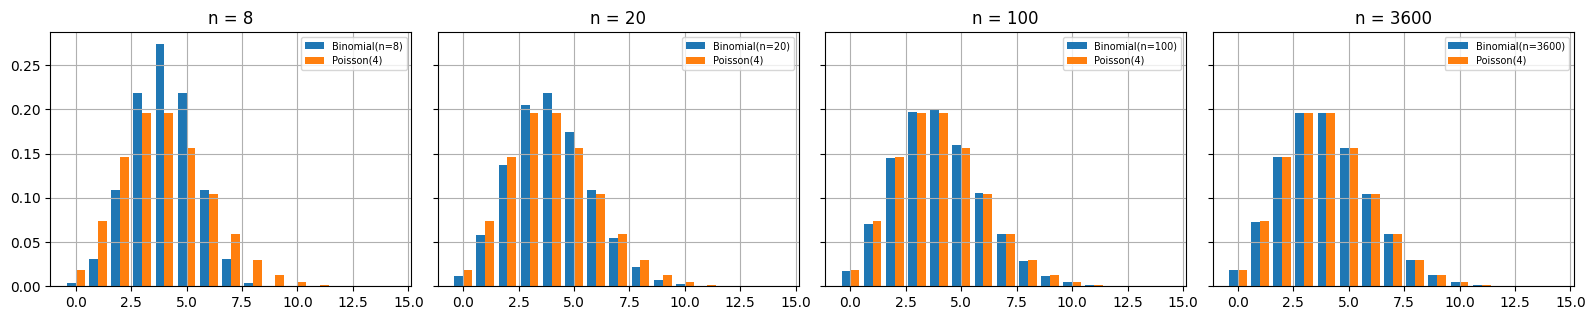

n =     8: max |Binomial - Poisson| = 0.078071
n =    20: max |Binomial - Poisson| = 0.022833
n =   100: max |Binomial - Poisson| = 0.004022
n =  3600: max |Binomial - Poisson| = 0.000109


In [3]:
lam = 4
k = np.arange(0, 15)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.3), sharey=True)
for ax, n in zip(axes, [8, 20, 100, 3600]):
    ax.bar(k - 0.2, stats.binom.pmf(k, n, lam / n), width=0.4, label=f"Binomial(n={n})")
    ax.bar(k + 0.2, stats.poisson.pmf(k, lam),      width=0.4, label="Poisson(4)")
    ax.legend(fontsize=7); ax.set_title(f"n = {n}")
plt.tight_layout(); plt.show()

# Max difference shrinks as n grows
for n in (8, 20, 100, 3600):
    diff = np.max(np.abs(stats.binom.pmf(k, n, lam/n) - stats.poisson.pmf(k, lam)))
    print(f"n = {n:5d}: max |Binomial - Poisson| = {diff:.6f}")

## 4. Mean and Variance

$$\boxed{E[X]=\lambda}\qquad\qquad\boxed{\text{Var}(X)=\lambda}\qquad\qquad\sigma=\sqrt\lambda$$

**The mean equals the variance.** This is the fingerprint of the Poisson distribution ("equidispersion"). It's used as a diagnostic on real data (Section 17).

### Proof of the mean
$$E[X]=\sum_{k=0}^\infty k\frac{e^{-\lambda}\lambda^k}{k!}=\lambda e^{-\lambda}\sum_{k=1}^\infty\frac{\lambda^{k-1}}{(k-1)!}=\lambda e^{-\lambda}e^{\lambda}=\lambda$$

### Proof of the variance
$$E[X(X-1)]=\sum_{k=2}^\infty k(k-1)\frac{e^{-\lambda}\lambda^k}{k!}=\lambda^2 e^{-\lambda}\sum_{k=2}^\infty\frac{\lambda^{k-2}}{(k-2)!}=\lambda^2$$
$$E[X^2]=E[X(X-1)]+E[X]=\lambda^2+\lambda\;\Rightarrow\;\text{Var}(X)=\lambda^2+\lambda-\lambda^2=\lambda$$

*(Also follows from the Binomial limit: np = λ and npq → λ as p → 0.)*

In [4]:
lam = 3.5
k = np.arange(0, 200)
pmf = stats.poisson.pmf(k, lam)

mean = np.sum(k * pmf)
ex_kk1 = np.sum(k * (k - 1) * pmf)
ex2 = np.sum(k**2 * pmf)
var = ex2 - mean**2

print(f"E[X]       numeric = {mean:.6f}   theory λ = {lam}")
print(f"E[X(X-1)]  numeric = {ex_kk1:.6f}   theory λ² = {lam**2}")
print(f"Var(X)     numeric = {var:.6f}   theory λ = {lam}")
print(f"SD = {np.sqrt(var):.4f} = sqrt(λ) = {sqrt(lam):.4f}")
print("Index of dispersion Var/Mean =", round(var/mean, 6))

E[X]       numeric = 3.500000   theory λ = 3.5
E[X(X-1)]  numeric = 12.250000   theory λ² = 12.25
Var(X)     numeric = 3.500000   theory λ = 3.5
SD = 1.8708 = sqrt(λ) = 1.8708
Index of dispersion Var/Mean = 1.0


**Mode:** the most likely value is $\lfloor\lambda\rfloor$. If λ is an integer, both λ and λ−1 are modes.

**Recursive formula (handy for hand-calculation):** $P(X=k+1)=\dfrac{\lambda}{k+1}P(X=k)$

In [5]:
for lam in (0.7, 2, 3.5, 7, 10):
    kk = np.arange(0, 40)
    pm = stats.poisson.pmf(kk, lam)
    modes = [int(m) for m in kk[np.isclose(pm, pm.max())]]
    print(f"λ = {lam:4}: mode(s) = {modes}")

# recursion check
lam = 3
p0 = exp(-lam)
p = [p0]
for k in range(0, 6):
    p.append(p[-1] * lam / (k + 1))
print("\nRecursive:", np.round(p, 5))
print("scipy    :", np.round(stats.poisson.pmf(range(7), lam), 5))

λ =  0.7: mode(s) = [0]
λ =    2: mode(s) = [1, 2]
λ =  3.5: mode(s) = [3]
λ =    7: mode(s) = [6, 7]
λ =   10: mode(s) = [9, 10]

Recursive: [0.04979 0.14936 0.22404 0.22404 0.16803 0.10082 0.05041]
scipy    : [0.04979 0.14936 0.22404 0.22404 0.16803 0.10082 0.05041]


## 5. Shape of the Distribution

* **Small λ (< 1)**: heavily right-skewed, with most of the mass at 0 (and mode 0).
* **As λ grows** it becomes more symmetric and bell-shaped.
* Skewness = $1/\sqrt\lambda$; excess kurtosis = $1/\lambda$ (both → 0 as λ → ∞).

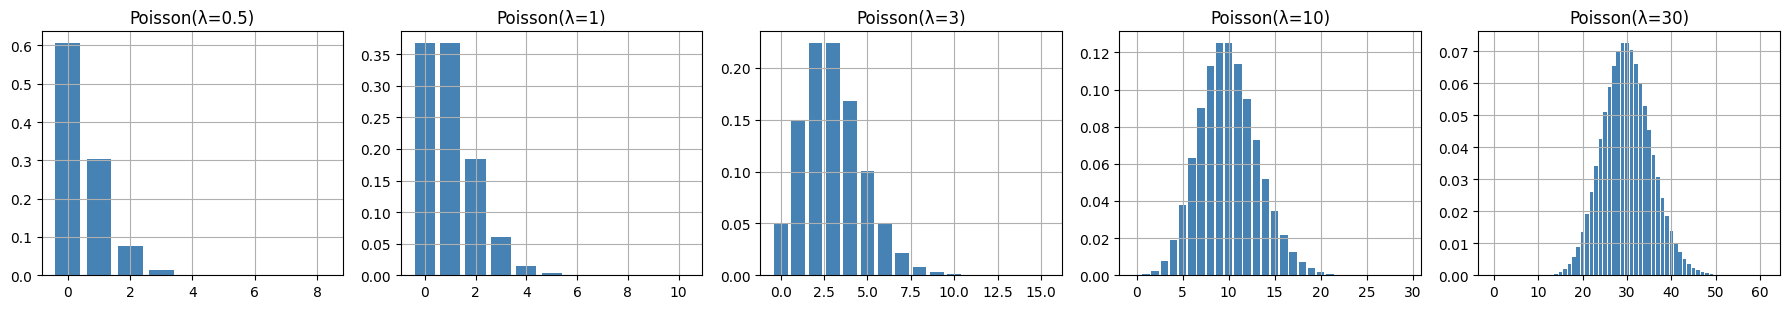

λ    skewness  kurtosis(excess)
0.5  1.414     2.000
3    0.577     0.333
30   0.183     0.033


In [6]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.2), sharey=False)
for ax, lam in zip(axes, [0.5, 1, 3, 10, 30]):
    k = np.arange(0, int(lam + 5 * sqrt(lam) + 5))
    ax.bar(k, stats.poisson.pmf(k, lam), color="steelblue")
    ax.set_title(f"Poisson(λ={lam})")
plt.tight_layout(); plt.show()

print("λ    skewness  kurtosis(excess)")
for lam in (0.5, 3, 30):
    s, kur = stats.poisson.stats(lam, moments="sk")
    print(f"{lam:<4} {float(s):.3f}     {float(kur):.3f}")

## 6. Cumulative Probabilities

| Question | Formula | scipy |
|---|---|---|
| Exactly k | $P(X=k)$ | `pmf(k)` |
| At most k | $P(X\le k)$ | `cdf(k)` |
| Fewer than k | $P(X\le k-1)$ | `cdf(k-1)` |
| At least k | $1-P(X\le k-1)$ | `sf(k-1)` |
| More than k | $1 - P(X \le k)$ | `sf(k)` |
| Between a and b | $P(X\le b)-P(X\le a-1)$ | `cdf(b)-cdf(a-1)` |
| **At least one** | $1-e^{-\lambda}$ | `1 - pmf(0)` |

In [7]:
lam = 4
X = stats.poisson(lam)

print("P(X = 6)          =", round(X.pmf(6), 4))
print("P(X <= 2)         =", round(X.cdf(2), 4))
print("P(X < 2)          =", round(X.cdf(1), 4))
print("P(X >= 7)         =", round(X.sf(6), 4))
print("P(X > 7)          =", round(X.sf(7), 4))
print("P(3 <= X <= 5)    =", round(X.cdf(5) - X.cdf(2), 4))
print("P(at least one)   =", round(1 - exp(-lam), 4), " (=1 - e^-λ)")

# The percentile/quantile function
print("\n90th percentile :", X.ppf(0.90), "  95th:", X.ppf(0.95), "  99th:", X.ppf(0.99))

P(X = 6)          = 0.1042
P(X <= 2)         = 0.2381
P(X < 2)          = 0.0916
P(X >= 7)         = 0.1107
P(X > 7)          = 0.0511
P(3 <= X <= 5)    = 0.547
P(at least one)   = 0.9817  (=1 - e^-λ)

90th percentile : 7.0   95th: 8.0   99th: 9.0


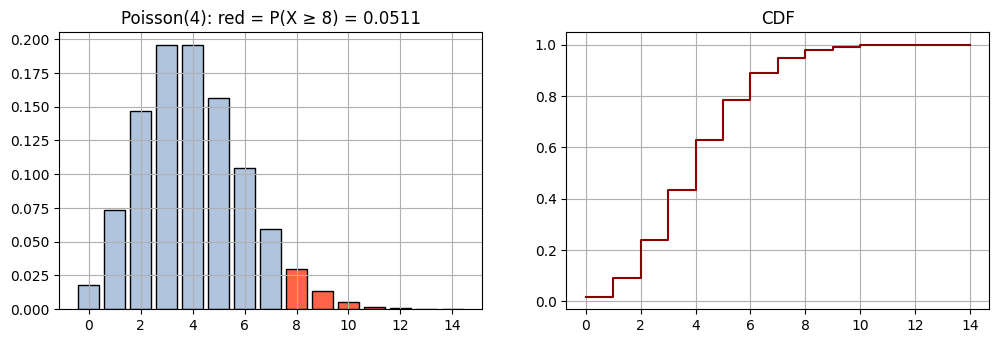

In [8]:
k = np.arange(0, 15)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
colors = ["tomato" if kk >= 8 else "lightsteelblue" for kk in k]
ax[0].bar(k, X.pmf(k), color=colors, edgecolor="black")
ax[0].set_title(f"Poisson(4): red = P(X ≥ 8) = {X.sf(7):.4f}")
ax[1].step(k, X.cdf(k), where="post", color="darkred"); ax[1].set_title("CDF")
plt.show()

## 7. Changing the Interval: Scaling λ

λ is a **rate × length of interval**. If events occur at rate r per unit time, then for an interval of length t:

$$X_t\sim\text{Poisson}(\lambda=r\,t)$$

Example: 12 calls per hour → in 10 minutes: λ = 12 × (10/60) = 2.

In [9]:
rate_per_hour = 12
for minutes in (5, 10, 30, 60, 120):
    lam = rate_per_hour * minutes / 60
    print(f"Interval {minutes:3d} min: λ = {lam:5.1f}   P(no calls) = {stats.poisson.pmf(0, lam):.4f}   P(≥1 call) = {stats.poisson.sf(0, lam):.4f}")

Interval   5 min: λ =   1.0   P(no calls) = 0.3679   P(≥1 call) = 0.6321
Interval  10 min: λ =   2.0   P(no calls) = 0.1353   P(≥1 call) = 0.8647
Interval  30 min: λ =   6.0   P(no calls) = 0.0025   P(≥1 call) = 0.9975
Interval  60 min: λ =  12.0   P(no calls) = 0.0000   P(≥1 call) = 1.0000
Interval 120 min: λ =  24.0   P(no calls) = 0.0000   P(≥1 call) = 1.0000


**Always match λ to the interval in the question.** A very common source of mistakes is using a per-hour λ for a per-minute question.

## 8. Sums and Splitting (Thinning)

**Sum:** if $X\sim\text{Poisson}(\lambda_1)$ and $Y\sim\text{Poisson}(\lambda_2)$ are independent, then
$$X+Y\sim\text{Poisson}(\lambda_1+\lambda_2)$$
(e.g. calls from two independent regions combine into one stream).

**Thinning:** if each event is independently "type A" with probability p, then type-A events are Poisson(pλ) and type-B events are Poisson((1−p)λ), and these two counts are **independent**.

In [10]:
lam1, lam2 = 2.0, 3.0
X = rng.poisson(lam1, 500_000)
Y = rng.poisson(lam2, 500_000)
S = X + Y

print("Sum: mean =", S.mean().round(3), " var =", S.var().round(3), " (both ≈ λ1+λ2 = 5)")
print("P(S = 4)   simulated:", np.mean(S == 4).round(4), "  Poisson(5):", stats.poisson.pmf(4, 5).round(4))

# Thinning: 10 orders/hour, 30% are express orders
lam, p = 10, 0.3
total = rng.poisson(lam, 500_000)
express = rng.binomial(total, p)            # each order is express with prob p
regular = total - express
print("\nThinning: express mean/var =", express.mean().round(3), express.var().round(3), " (theory 3)")
print("          regular mean/var =", regular.mean().round(3), regular.var().round(3), " (theory 7)")
print("          corr(express, regular) =", np.corrcoef(express, regular)[0, 1].round(4), " (≈ 0 => independent)")

Sum: mean = 5.0  var = 5.005  (both ≈ λ1+λ2 = 5)
P(S = 4)   simulated: 0.1758   Poisson(5): 0.1755

Thinning: express mean/var = 3.002 2.992  (theory 3)
          regular mean/var = 7.002 7.016  (theory 7)
          corr(express, regular) = 0.0016  (≈ 0 => independent)


## 9. Poisson Process: Link with Exponential & Geometric Distributions

In a Poisson process with rate λ per unit time:
* **Number** of events in time t → Poisson(λt)
* **Waiting time** between consecutive events → **Exponential(λ)**, with mean 1/λ
* Discrete-time analogue of waiting: **Geometric**

So Poisson **counts** and Exponential **gaps** are two views of the same process.

$$P(\text{no event in } [0,t])=e^{-\lambda t}=P(\text{wait}>t)$$

Mean events/hour: 1.992   Var: 2.015  (both ≈ 2)


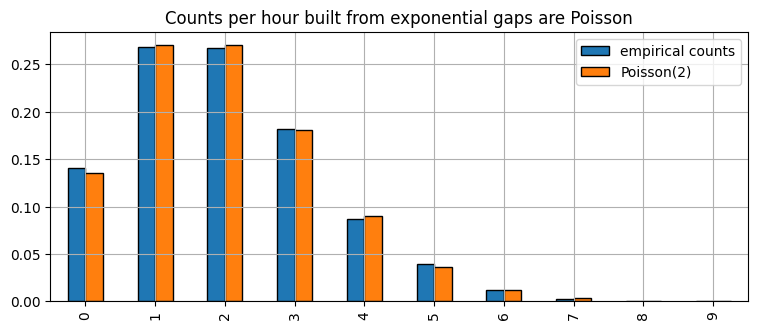


Mean gap: 0.5009 hours  (theory 1/λ = 0.5)
P(gap > 1 hour): sim 0.1368  theory e^-2 = 0.1353  = P(0 events in an hour)


In [11]:
lam = 2          # events per hour
T = 10_000       # hours simulated
# generate event times from exponential gaps
gaps = rng.exponential(1/lam, size=int(lam * T * 1.2))
times = np.cumsum(gaps)
times = times[times < T]

# count events in each 1-hour window -> should be Poisson(2)
counts = np.histogram(times, bins=np.arange(0, T + 1))[0]
print("Mean events/hour:", counts.mean().round(3), "  Var:", counts.var().round(3), " (both ≈ 2)")

emp = pd.Series(counts).value_counts(normalize=True).sort_index().iloc[:10]
theo = pd.Series(stats.poisson.pmf(emp.index, lam), index=emp.index)
pd.DataFrame({"empirical counts": emp, "Poisson(2)": theo}).plot(kind="bar", figsize=(9, 3.5), edgecolor="black")
plt.title("Counts per hour built from exponential gaps are Poisson"); plt.show()

print("\nMean gap:", gaps.mean().round(4), "hours  (theory 1/λ = 0.5)")
print("P(gap > 1 hour): sim", np.mean(gaps > 1).round(4), " theory e^-2 =", round(exp(-2), 4), " = P(0 events in an hour)")

## 10. Poisson Approximation to the Binomial

Use Poisson(np) instead of Binomial(n, p) when **n is large (≥ 20–100)** and **p is small (≤ 0.05–0.1)**. It's handy when n is huge or unknown but the rate np is known.

Total variation distance: 0.00494
P(X <= 8)  exact binomial: 0.33054   Poisson: 0.33282


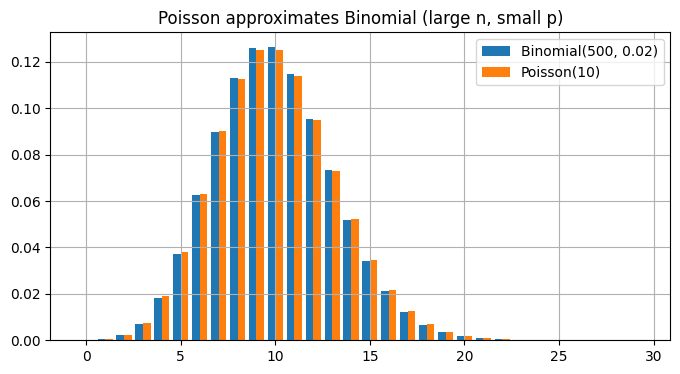

In [12]:
# 2% of 500 printed circuit boards are faulty -> n=500, p=0.02, λ=10 ... test approximation quality
n, p = 500, 0.02
lam = n * p
k = np.arange(0, 30)

exact = stats.binom.pmf(k, n, p)
approx = stats.poisson.pmf(k, lam)
print("Total variation distance:", round(0.5 * np.abs(exact - approx).sum(), 5))
print("P(X <= 8)  exact binomial:", round(stats.binom.cdf(8, n, p), 5), "  Poisson:", round(stats.poisson.cdf(8, lam), 5))

plt.bar(k - 0.2, exact, width=0.4, label="Binomial(500, 0.02)")
plt.bar(k + 0.2, approx, width=0.4, label="Poisson(10)")
plt.legend(); plt.title("Poisson approximates Binomial (large n, small p)"); plt.show()

In [13]:
# When does it work? Compare for different p (n fixed)
n = 100
print("p      λ=np   max|Bin - Poi|")
for p in (0.01, 0.03, 0.05, 0.1, 0.3, 0.5):
    k = np.arange(0, n + 1)
    d = np.max(np.abs(stats.binom.pmf(k, n, p) - stats.poisson.pmf(k, n * p)))
    print(f"{p:<6} {n*p:<6} {d:.5f}")

p      λ=np   max|Bin - Poi|
0.01   1.0    0.00185
0.03   3.0    0.00343
0.05   5.0    0.00455
0.1    10.0   0.00676
0.3    30.0   0.01415
0.5    50.0   0.02326


## 11. Normal Approximation to the Poisson

For **large λ (≥ ~10–20)**: Poisson(λ) ≈ Normal(μ = λ, σ² = λ), with continuity correction $P(X\le k)\approx P(Y\le k+0.5)$.

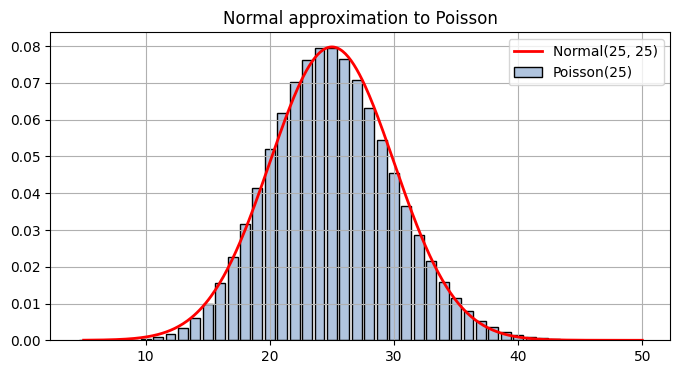

P(X <= 30) exact                 = 0.8633
Normal, no continuity correction = 0.8413
Normal, with correction (30.5)   = 0.8643


In [14]:
lam = 25
X = stats.poisson(lam)
k = np.arange(5, 50)
xs = np.linspace(5, 50, 400)

plt.bar(k, X.pmf(k), color="lightsteelblue", edgecolor="black", label="Poisson(25)")
plt.plot(xs, stats.norm.pdf(xs, lam, sqrt(lam)), "r-", lw=2, label="Normal(25, 25)")
plt.legend(); plt.title("Normal approximation to Poisson"); plt.show()

exact = X.cdf(30)
print(f"P(X <= 30) exact                 = {exact:.4f}")
print(f"Normal, no continuity correction = {stats.norm.cdf(30, lam, sqrt(lam)):.4f}")
print(f"Normal, with correction (30.5)   = {stats.norm.cdf(30.5, lam, sqrt(lam)):.4f}")

## 12. Simulation Check

Simulated: mean=6.498, var=6.493   Theory: 6.5, 6.5


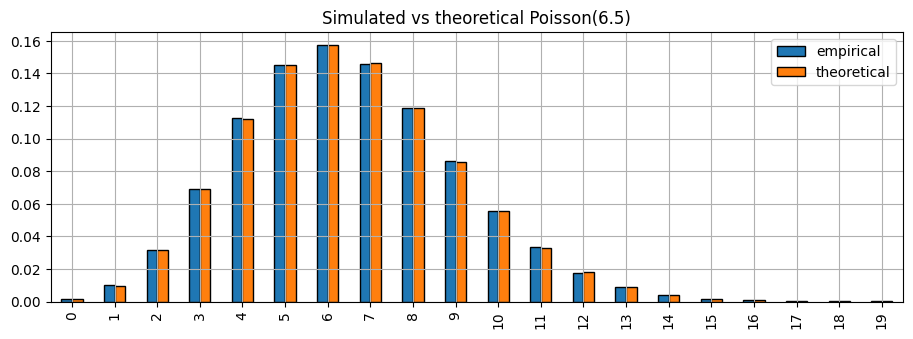

In [15]:
lam, reps = 6.5, 500_000
sim = rng.poisson(lam, reps)
print(f"Simulated: mean={sim.mean():.3f}, var={sim.var():.3f}   Theory: {lam}, {lam}")

emp = pd.Series(sim).value_counts(normalize=True).sort_index().iloc[:20]
theo = pd.Series(stats.poisson.pmf(emp.index, lam), index=emp.index)
pd.DataFrame({"empirical": emp, "theoretical": theo}).plot(kind="bar", figsize=(11, 3.5), edgecolor="black")
plt.title("Simulated vs theoretical Poisson(6.5)"); plt.show()

---
# Real-Life Case Studies
---

## 13. Case Study 1: Call-Centre Staffing

A customer-support centre receives on average **λ = 6 calls per 10-minute window** during the afternoon. Calls are independent. Each agent can handle **one call per 10-minute window** (simplification), so the number of agents needed in a window = number of calls.

**Manager's questions**
1. What's the probability of **no calls** in a window? Of **exactly 6**?
2. If the centre keeps **8 agents**, how often will calls exceed capacity (customers wait)?
3. How many agents are needed so that overflow happens **at most 5% / 1%** of the time?
4. Cost trade-off: each idle agent costs ₹200/window (wasted); each unserved call costs ₹500 (lost customer). What staffing level minimises expected cost?

In [16]:
lam = 6
X = stats.poisson(lam)

print("1. P(no calls)   =", round(X.pmf(0), 4), "   P(exactly 6) =", round(X.pmf(6), 4))
print("2. Overflow with 8 agents = P(X > 8) =", round(X.sf(8), 4))

print("\n3. Staffing for service level:")
for target in (0.05, 0.01):
    agents = int(X.ppf(1 - target))
    print(f"   Overflow <= {target:.0%}: need {agents} agents (overflow prob = {X.sf(agents):.4f})")

1. P(no calls)   = 0.0025    P(exactly 6) = 0.1606
2. Overflow with 8 agents = P(X > 8) = 0.1528

3. Staffing for service level:
   Overflow <= 5%: need 10 agents (overflow prob = 0.0426)
   Overflow <= 1%: need 12 agents (overflow prob = 0.0088)


 agents  E[idle]  E[lost calls]  expected cost (₹)  P(overflow)
      0    0.000          6.000           3000.000        0.998
      1    0.002          5.002           2501.735        0.983
      2    0.020          4.020           2013.881        0.938
      3    0.082          3.082           1557.259        0.849
      4    0.233          2.233           1163.102        0.715
      5    0.518          1.518            862.641        0.554
      6    0.964          0.964            674.617        0.394
      7    1.570          0.570            599.029        0.256
      8    2.314          0.314            619.815        0.153
      9    3.161          0.161            712.881        0.084
     10    4.077          0.077            854.134        0.043
     11    5.035          0.035           1024.300        0.020
     12    6.015          0.015           1210.235        0.009
     13    7.006          0.006           1404.056        0.004
     14    8.002          0.002         

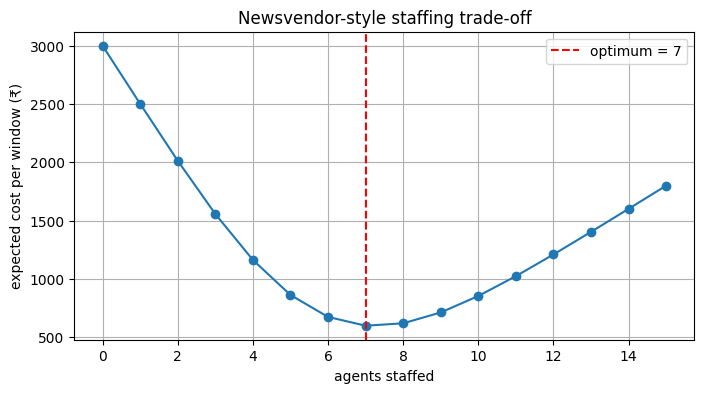

In [17]:
# Q4: expected cost for staffing s = 0..15
idle_cost, lost_cost = 200, 500
k = np.arange(0, 100)
pmf = X.pmf(k)

rows = []
for s in range(0, 16):
    idle = np.sum(np.maximum(s - k, 0) * pmf)          # expected idle agents
    lost = np.sum(np.maximum(k - s, 0) * pmf)          # expected unserved calls
    rows.append({"agents": s, "E[idle]": idle, "E[lost calls]": lost,
                 "expected cost (₹)": idle * idle_cost + lost * lost_cost,
                 "P(overflow)": X.sf(s)})
staff = pd.DataFrame(rows).round(3)
print(staff.to_string(index=False))

best = staff.loc[staff["expected cost (₹)"].idxmin()]
print(f"\nCost-minimising staffing: {int(best['agents'])} agents, expected cost ₹{best['expected cost (₹)']:.0f}")

plt.plot(staff["agents"], staff["expected cost (₹)"], "o-")
plt.axvline(best["agents"], color="red", ls="--", label=f"optimum = {int(best['agents'])}")
plt.xlabel("agents staffed"); plt.ylabel("expected cost per window (₹)")
plt.title("Newsvendor-style staffing trade-off"); plt.legend(); plt.show()

### 💡 Insights from Case Study 1
* **Staffing to the average (6) is a trap**: a Poisson(6) count exceeds 6 about 39% of the time. Average-staffing means customers wait *often*.
* Because SD = √λ ≈ 2.4, natural fluctuation is large. **Capacity must include a buffer above the mean** (here about +4 to +6 agents above the mean for a 5%-1% overflow target).
* The buffer needed grows like √λ, so **bigger centres are more efficient**: buffer as a fraction of load shrinks (economies of scale / pooling).
* The cost-optimal level is set by the ratio of costs (lost call vs idle agent), not by a fixed rule.

In [18]:
# Pooling / economies of scale: buffer needed for 95% service level as load grows
rows = []
for lam_ in (2, 6, 20, 60, 200, 600):
    s95 = int(stats.poisson.ppf(0.95, lam_))
    rows.append({"average load λ": lam_, "agents for 95%": s95, "buffer": s95 - lam_,
                 "buffer as % of load": round(100 * (s95 - lam_) / lam_, 1)})
print(pd.DataFrame(rows).to_string(index=False))

 average load λ  agents for 95%  buffer  buffer as % of load
              2               5       3                150.0
              6              10       4                 66.7
             20              28       8                 40.0
             60              73      13                 21.7
            200             224      24                 12.0
            600             641      41                  6.8


## 14. Case Study 2: Hospital Emergency Room

An ER records on average **2.4 serious trauma arrivals per night shift** (8 hours). Assume Poisson arrivals.

**Questions**
1. What's the chance of a **quiet night** (0 arrivals)?
2. The ER has **5 trauma beds**. How often is it overwhelmed (> 5 arrivals) in a shift?
3. Over a **week (7 shifts)** how many "overwhelmed" nights do we expect? P(at least 2 overwhelmed nights in a week)?
4. One night saw **9 arrivals**. Is that a statistically unusual event?

In [19]:
lam = 2.4
X = stats.poisson(lam)

print("1. P(quiet night, 0 arrivals) =", round(X.pmf(0), 4))
p_over = X.sf(5)
print("2. P(overwhelmed: more than 5)  =", round(p_over, 5), f"  -> about 1 night in {1/p_over:.0f}")

# 3. Number of overwhelmed nights in 7 shifts is Binomial(7, p_over)
W = stats.binom(7, p_over)
print(f"3. Expected overwhelmed nights per week = {W.mean():.3f}")
print(f"   P(at least 2 in a week) = {W.sf(1):.5f}")
print(f"   Expected overwhelmed nights per year (365 shifts) = {365 * p_over:.1f}")

print(f"\n4. P(X >= 9) = {X.sf(8):.6f}  -> one in {1/X.sf(8):,.0f} nights")

1. P(quiet night, 0 arrivals) = 0.0907
2. P(overwhelmed: more than 5)  = 0.03567   -> about 1 night in 28
3. Expected overwhelmed nights per week = 0.250
   P(at least 2 in a week) = 0.02371
   Expected overwhelmed nights per year (365 shifts) = 13.0

4. P(X >= 9) = 0.000862  -> one in 1,160 nights


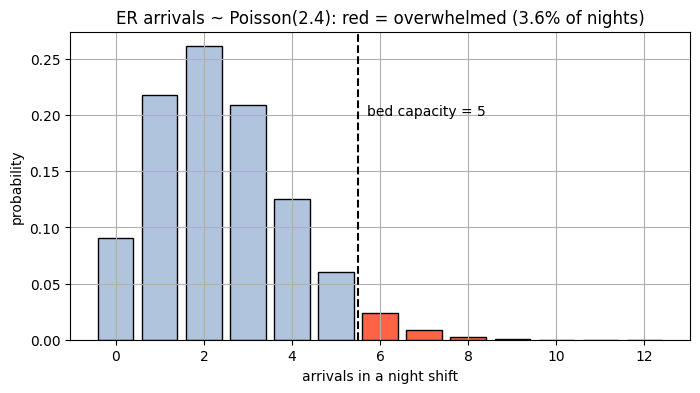

In [20]:
k = np.arange(0, 13)
colors = ["tomato" if kk > 5 else "lightsteelblue" for kk in k]
plt.bar(k, X.pmf(k), color=colors, edgecolor="black")
plt.axvline(5.5, color="k", ls="--"); plt.text(5.7, 0.2, "bed capacity = 5")
plt.xlabel("arrivals in a night shift"); plt.ylabel("probability")
plt.title(f"ER arrivals ~ Poisson(2.4): red = overwhelmed ({p_over:.1%} of nights)"); plt.show()

### 💡 Insights from Case Study 2
* Even with capacity *more than double* the mean (5 beds vs 2.4 avg), the ER is still overwhelmed **~3.6% of nights** (≈ 13 nights a year). Rare-but-not-negligible tail events are a feature of Poisson processes.
* **Combining Poisson with Binomial** answers multi-period questions: (Poisson) "arrivals per night" → (Binomial) "how many bad nights per week".
* A count of **9** at λ = 2.4 has a p-value of ~0.0009, which is strong evidence that *something changed* (an accident, an outbreak, a data problem). This is the basis of **anomaly / outbreak detection** (see the next case study).
* Rare-event planning: hospitals use surge plans because the average alone hides the tail.

## 15. Case Study 3: Website Server Load & Anomaly Detection

An e-commerce website normally sees **λ = 30 requests per second** for a specific API endpoint. Requests are independent.

**Questions**
1. What is the "normal range" (99% of seconds)?
2. The system raises an alert when a second has more than a threshold T requests. What T gives a false-alarm rate of ≈ 1 per 10,000 seconds?
3. During a suspicious incident the monitoring saw **55 requests in a second**. How unlikely is it under normal load?
4. **Sustained attack:** what if the rate doubles to 60/s? How quickly does the T-based alarm detect it?

In [21]:
lam = 30
X = stats.poisson(lam)

lo, hi = X.ppf(0.005), X.ppf(0.995)
print(f"1. 99% of seconds have between {int(lo)} and {int(hi)} requests (mean {lam}, SD {sqrt(lam):.2f})")

# 2. threshold for false alarm rate 1e-4
T = int(X.ppf(1 - 1e-4))
print(f"2. Threshold T = {T}: false-alarm probability per second = {X.sf(T):.6f}")

print(f"3. P(X >= 55 | λ=30) = {X.sf(54):.2e}  -> extremely unlikely by chance")

# 4. detection under attack
Xa = stats.poisson(60)
p_detect = Xa.sf(T)
print(f"4. If rate is 60/s: P(alarm in any given second) = {p_detect:.4f}")
print(f"   Expected seconds until detection (geometric) = {1/p_detect:.2f}")

1. 99% of seconds have between 17 and 45 requests (mean 30, SD 5.48)
2. Threshold T = 52: false-alarm probability per second = 0.000093
3. P(X >= 55 | λ=30) = 2.71e-05  -> extremely unlikely by chance
4. If rate is 60/s: P(alarm in any given second) = 0.8334
   Expected seconds until detection (geometric) = 1.20


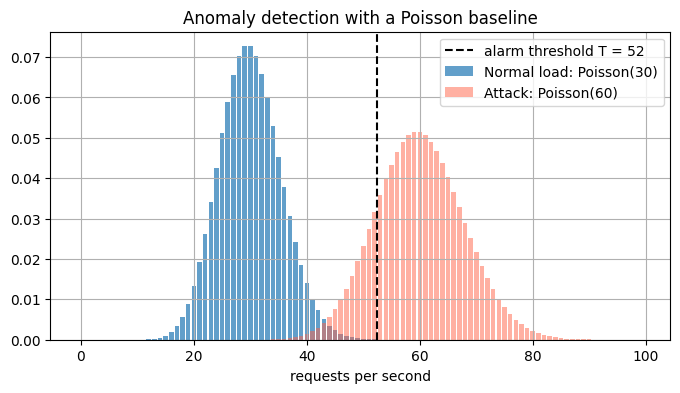

In [22]:
k = np.arange(0, 100)
plt.bar(k, X.pmf(k), alpha=0.7, label="Normal load: Poisson(30)")
plt.bar(k, Xa.pmf(k), alpha=0.5, color="tomato", label="Attack: Poisson(60)")
plt.axvline(T + 0.5, color="k", ls="--", label=f"alarm threshold T = {T}")
plt.xlabel("requests per second"); plt.legend(); plt.title("Anomaly detection with a Poisson baseline"); plt.show()

Number of alert seconds: 253
  during attack (true positives): 251 of 300 seconds
  false alarms                  : 2  (expected ≈ 8.6)
  first alert in attack after 0 seconds


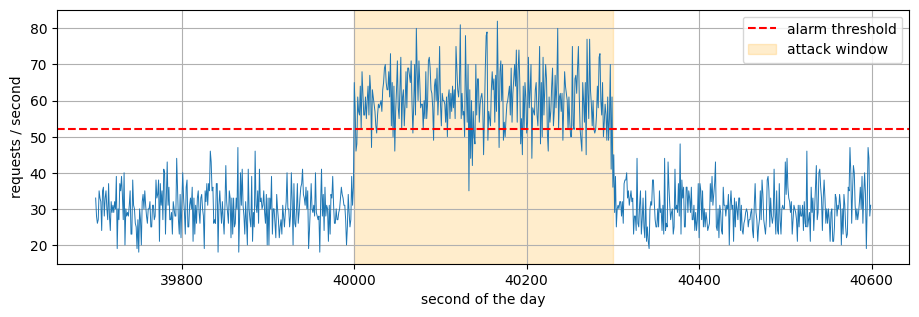

In [23]:
# Simulate a day (86,400 seconds): normal traffic, with an attack from second 40,000 to 40,300
seconds = 86_400
rate = np.full(seconds, 30.0)
rate[40_000:40_300] = 60.0
traffic = rng.poisson(rate)
alerts = np.where(traffic > T)[0]

print("Number of alert seconds:", len(alerts))
in_attack = alerts[(alerts >= 40_000) & (alerts < 40_300)]
false_alarms = alerts[(alerts < 40_000) | (alerts >= 40_300)]
print(f"  during attack (true positives): {len(in_attack)} of 300 seconds")
print(f"  false alarms                  : {len(false_alarms)}  (expected ≈ {(seconds-300)*1e-4:.1f})")
print(f"  first alert in attack after {in_attack[0]-40_000 if len(in_attack) else 'N/A'} seconds")

fig, ax = plt.subplots(figsize=(11, 3.3))
ax.plot(np.arange(39_700, 40_600), traffic[39_700:40_600], lw=0.7)
ax.axhline(T, color="red", ls="--", label="alarm threshold")
ax.axvspan(40_000, 40_300, color="orange", alpha=0.2, label="attack window")
ax.set_xlabel("second of the day"); ax.set_ylabel("requests / second"); ax.legend(); plt.show()

### 💡 Insights from Case Study 3
* Thresholds derived from the **Poisson tail** give a *quantified* false-alarm rate, better than "mean ± something" guesses.
* Notice the natural range at λ = 30 is roughly 17–45, so ordinary seconds already fluctuate by ±15. A spike to 40 is **not** an incident.
* When the rate doubles, the alarm almost surely fires within a second or two: **detection delay ~ Geometric**, tying together the Poisson and geometric ideas.
* **Trade-off:** raising T reduces false alarms but slows down detection of *small* increases (try λ_attack = 40 to see how much harder it is).

In [24]:
# How detection power depends on attack size, for the same threshold T
rows = []
for lam_att in (30, 35, 40, 50, 60, 90):
    p_det = stats.poisson.sf(T, lam_att)
    rows.append({"true rate": lam_att, "P(alarm per second)": p_det,
                 "expected seconds to detect": np.inf if p_det == 0 else 1/p_det})
print(pd.DataFrame(rows).round(5).to_string(index=False))

 true rate  P(alarm per second)  expected seconds to detect
        30              0.00009                 10738.17393
        35              0.00273                   366.05348
        40              0.02806                    35.64144
        50              0.35417                     2.82353
        60              0.83335                     1.19997
        90              0.99999                     1.00001


## 16. Case Study 4: Football Goals: Fitting Data & Goodness of Fit

The number of goals scored by a team in a match is a classic Poisson example (rare, roughly independent scoring events over a fixed 90 minutes). We simulate a realistic "season" dataset of a league (380 matches, ~2.7 goals per match total across two teams → 760 team-performances), and test whether Poisson fits.

> Note: this uses simulated data resembling real league statistics. Replace `goals` with your own data column to apply the same analysis.

In [25]:
goals = rng.poisson(1.35, 760)                     # team-goals per match (avg ~1.35)

freq = pd.Series(goals).value_counts().sort_index()
print("Goals scored per team per match:")
print(freq.to_string())
print(f"\nMean = {goals.mean():.3f}, Variance = {goals.var(ddof=1):.3f}  -> variance ≈ mean, consistent with Poisson")

Goals scored per team per match:
0    189
1    260
2    194
3     70
4     35
5      9
6      2
7      1

Mean = 1.397, Variance = 1.433  -> variance ≈ mean, consistent with Poisson


 goals  observed  expected (Poisson)
     0       189               187.9
     1       260               262.6
     2       194               183.5
     3        70                85.5
     4        35                29.9
     5         9                 8.3
     6         2                 1.9
     7         1                 0.4


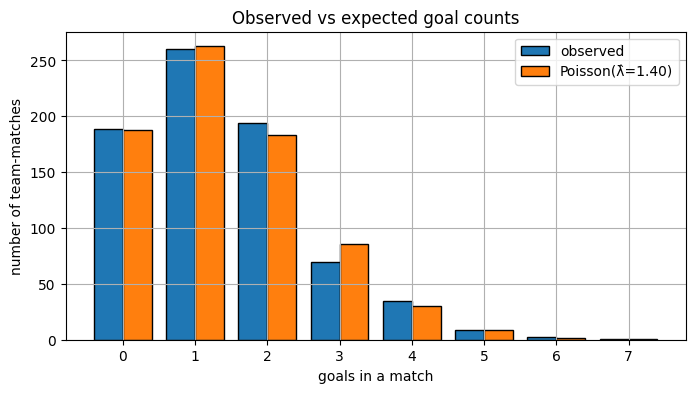

In [26]:
lam_hat = goals.mean()                 # MLE for λ
k = np.arange(0, freq.index.max() + 1)
observed = np.array([np.sum(goals == kk) for kk in k])
expected = len(goals) * stats.poisson.pmf(k, lam_hat)

comparison = pd.DataFrame({"goals": k, "observed": observed, "expected (Poisson)": expected.round(1)})
print(comparison.to_string(index=False))

x = np.arange(len(k))
plt.bar(x - 0.2, observed, width=0.4, label="observed", edgecolor="black")
plt.bar(x + 0.2, expected, width=0.4, label=f"Poisson(λ̂={lam_hat:.2f})", edgecolor="black")
plt.xticks(x, k); plt.xlabel("goals in a match"); plt.ylabel("number of team-matches"); plt.legend()
plt.title("Observed vs expected goal counts"); plt.show()

In [27]:
# Chi-square goodness-of-fit test (pool tail so that expected counts >= 5)
obs = observed.astype(float).copy()
exp_ = expected.copy()
# pool the last categories with expected < 5 into the previous one
while exp_[-1] < 5:
    obs[-2] += obs[-1]; exp_[-2] += exp_[-1]
    obs, exp_ = obs[:-1], exp_[:-1]
# make the last bin "k or more" so probabilities sum to 1
exp_ = exp_ * (obs.sum() / exp_.sum())

chi2 = np.sum((obs - exp_)**2 / exp_)
dof = len(obs) - 1 - 1                 # minus 1 (total) minus 1 (estimated λ)
p_value = stats.chi2.sf(chi2, dof)
print(f"χ² = {chi2:.3f}, dof = {dof}, p-value = {p_value:.3f}")
print("Conclusion:", "no evidence against Poisson (fits well)" if p_value > 0.05 else "Poisson fit is rejected")

χ² = 4.484, dof = 4, p-value = 0.344
Conclusion: no evidence against Poisson (fits well)


Home win: 0.490 | Draw: 0.249 | Away win: 0.262
Most likely scoreline: (1, 1)   (home, away)  prob = 0.118
P(over 2.5 total goals) = 0.506   (sum of Poissons is Poisson)


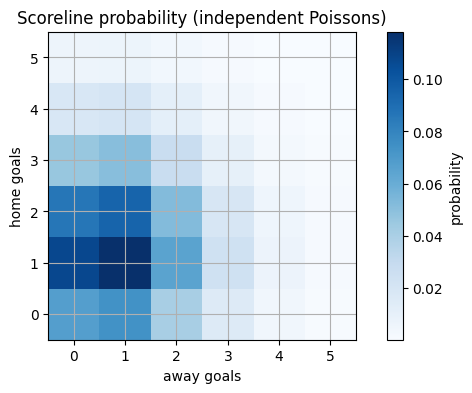

In [28]:
# Application: match-outcome probabilities with two independent Poisson scores
lam_home, lam_away = 1.6, 1.1
max_g = 10
grid = np.outer(stats.poisson.pmf(range(max_g + 1), lam_home),
                stats.poisson.pmf(range(max_g + 1), lam_away))

home_win = np.tril(grid, -1).sum()
draw     = np.trace(grid)
away_win = np.triu(grid, 1).sum()
print(f"Home win: {home_win:.3f} | Draw: {draw:.3f} | Away win: {away_win:.3f}")
print(f"Most likely scoreline: {tuple(int(v) for v in np.unravel_index(grid.argmax(), grid.shape))}   (home, away)  prob = {grid.max():.3f}")
print(f"P(over 2.5 total goals) = {stats.poisson.sf(2, lam_home + lam_away):.3f}   (sum of Poissons is Poisson)")

plt.imshow(grid[:6, :6], cmap="Blues", origin="lower")
plt.colorbar(label="probability"); plt.xlabel("away goals"); plt.ylabel("home goals")
plt.title("Scoreline probability (independent Poissons)"); plt.show()

### 💡 Insights from Case Study 4
* When **mean ≈ variance** and the observed histogram tracks the Poisson curve, the model is credible.
* The Poisson model gives a full probability table of scorelines, from which betting odds, league forecasts and "over/under" markets are built (with refinements such as team strength and home advantage: the Dixon-Coles / Maher models).
* The **sum of independent Poissons is Poisson**, so total goals is Poisson(λ_home + λ_away).
* Real data often shows *slight* deviations (e.g. correlation between teams or more 0-0 draws than expected), and testing is how you find out.

## 17. Estimating λ from Data (MLE), Confidence Intervals & Testing Over-Dispersion

### Maximum likelihood estimate
For observations $x_1,\dots,x_m$ from Poisson(λ):  $\hat\lambda=\bar x$ (the sample mean).

### Approximate 95% confidence interval
$$\hat\lambda\pm1.96\sqrt{\hat\lambda/m}$$
(or an *exact* CI via the chi-square relationship).

### Over-dispersion check
Real count data are often **over-dispersed** (variance > mean), because rates vary across time or people. Compute the index of dispersion; if it's much greater than 1, Poisson is too narrow (use Negative Binomial instead).

In [29]:
true_lam = 4.2
data = rng.poisson(true_lam, 60)          # 60 hourly counts
m = len(data)
lam_hat = data.mean()
se = np.sqrt(lam_hat / m)

print(f"λ̂ = {lam_hat:.3f}   standard error = {se:.3f}")
print(f"Approx 95% CI: ({lam_hat - 1.96*se:.3f}, {lam_hat + 1.96*se:.3f})")

# exact (Garwood) interval using chi-square
tot = data.sum()
lo = stats.chi2.ppf(0.025, 2 * tot) / 2 / m
hi = stats.chi2.ppf(0.975, 2 * (tot + 1)) / 2 / m
print(f"Exact 95% CI : ({lo:.3f}, {hi:.3f})")
print("True λ inside CI?", lo <= true_lam <= hi)

λ̂ = 4.033   standard error = 0.259
Approx 95% CI: (3.525, 4.542)
Exact 95% CI : (3.541, 4.575)
True λ inside CI? True


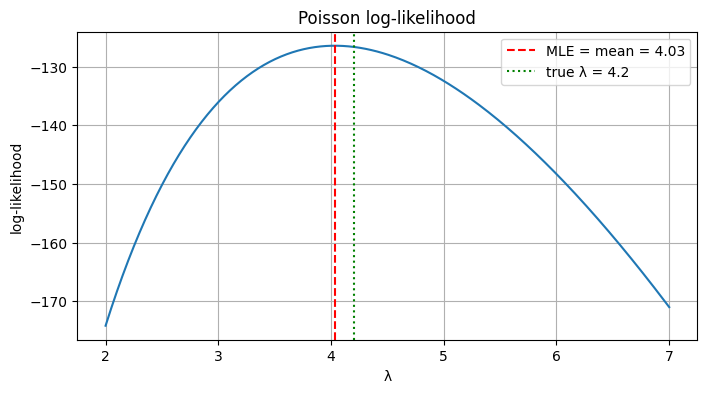

In [30]:
# Log-likelihood peaks at the sample mean
grid = np.linspace(2, 7, 300)
ll = [np.sum(stats.poisson.logpmf(data, g)) for g in grid]
plt.plot(grid, ll); plt.axvline(lam_hat, color="red", ls="--", label=f"MLE = mean = {lam_hat:.2f}")
plt.axvline(true_lam, color="green", ls=":", label=f"true λ = {true_lam}"); plt.legend()
plt.xlabel("λ"); plt.ylabel("log-likelihood"); plt.title("Poisson log-likelihood"); plt.show()

Poisson data      : Var/Mean = 1.19, p-value(over-dispersion) = 0.034
Varying-rate data : Var/Mean = 3.35, p-value(over-dispersion) = 1.00e-51  -> NOT Poisson


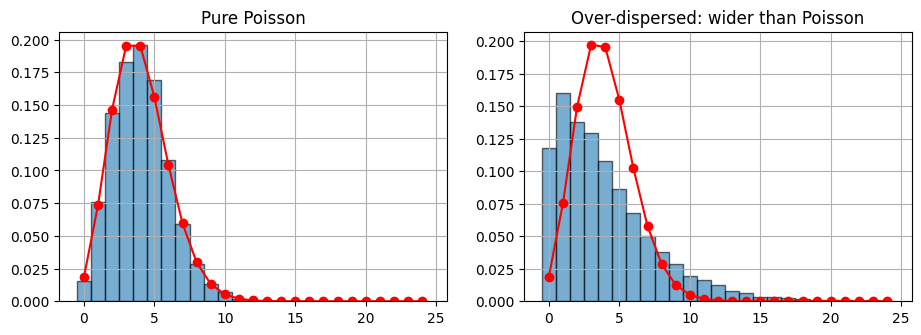

In [31]:
# Dispersion test: (m-1)*s²/x̄ ~ chi-square(m-1) under Poisson
def dispersion_test(x):
    x = np.asarray(x); m = len(x)
    D = (m - 1) * x.var(ddof=1) / x.mean()
    p_over = stats.chi2.sf(D, m - 1)               # H1: over-dispersed
    return x.var(ddof=1) / x.mean(), D, p_over

# 1. genuinely Poisson
idx, D, p = dispersion_test(rng.poisson(4, 200))
print(f"Poisson data      : Var/Mean = {idx:.2f}, p-value(over-dispersion) = {p:.3f}")

# 2. Over-dispersed data: rate itself varies (gamma-Poisson = negative binomial)
rates = rng.gamma(shape=2, scale=2, size=200)      # mean rate 4, but varying
x = rng.poisson(rates)
idx, D, p = dispersion_test(x)
print(f"Varying-rate data : Var/Mean = {idx:.2f}, p-value(over-dispersion) = {p:.2e}  -> NOT Poisson")

# Show histograms
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
k = np.arange(0, 25)
ax[0].hist(rng.poisson(4, 5000), bins=np.arange(-0.5, 25), density=True, alpha=0.6, edgecolor="black")
ax[0].plot(k, stats.poisson.pmf(k, 4), "ro-"); ax[0].set_title("Pure Poisson")
xs = rng.poisson(rng.gamma(2, 2, 5000))
ax[1].hist(xs, bins=np.arange(-0.5, 25), density=True, alpha=0.6, edgecolor="black")
ax[1].plot(k, stats.poisson.pmf(k, xs.mean()), "ro-"); ax[1].set_title("Over-dispersed: wider than Poisson")
plt.show()

### 💡 Insight
If real data show Var/Mean ≫ 1 (bursty arrivals, clustering, heterogeneous customers), a plain Poisson will **underestimate the risk of extreme values**. That mistake is costly in staffing, insurance and network capacity planning. Use the Negative Binomial or a mixture model.

## 18. Cheat-Sheet, Key Insights & Practice

### Formulas
| Item | Formula |
|---|---|
| PMF | $P(X=k)=\dfrac{e^{-\lambda}\lambda^k}{k!}$ |
| Mean | $\lambda$ |
| Variance | $\lambda$ (mean = variance) |
| Std dev | $\sqrt\lambda$ |
| Mode | $\lfloor\lambda\rfloor$ |
| Recursion | $P(k+1)=\frac{\lambda}{k+1}P(k)$ |
| P(at least one) | $1-e^{-\lambda}$ |
| Scaling | λ for interval t = rate × t |
| Sum | Poisson(λ₁) + Poisson(λ₂) = Poisson(λ₁+λ₂) |
| Thinning | keep with prob p → Poisson(pλ) |
| Binomial approx. | Bin(n,p) ≈ Poisson(np) if n large, p small |
| Normal approx. | N(λ, λ) if λ ≳ 10–20 |
| MLE | $\hat\lambda=\bar x$ |
| Waiting time between events | Exponential(λ), mean 1/λ |

### When to use which distribution
| Question | Distribution |
|---|---|
| Successes in n fixed trials | Binomial |
| Trials until first success | Geometric |
| Events in a fixed interval (no fixed n) | **Poisson** |
| Time between events | Exponential |

### Top real-life insights
1. **Mean = variance = λ** is the signature. If data show variance ≫ mean, Poisson understates risk.
2. **Average-based planning fails:** fluctuations are ~√λ, so you must add a buffer (percentile-based capacity).
3. **Bigger systems are relatively steadier** (√λ/λ = 1/√λ), so pooling resources reduces the *relative* buffer needed.
4. **Rare ≠ impossible:** tail events (overwhelmed ER, traffic spikes) occur regularly over enough time. Compute their frequency rather than ignore it.
5. **Tails give principled alarms:** thresholds from Poisson tails give controlled false-alarm rates for anomaly detection.
6. **Always match λ to the interval** in the question (rate × length).
7. **Check the assumptions:** independence and constant rate. Rush hours, clustering, contagion and outages break them.

### Practice problems
1. A book has on average 2 typos per page. Find P(no typos on a page), P(at most 3 typos), and P(exactly 5 typos in 2 pages).
2. A bank branch gets 15 customers/hour. What's the probability of more than 20 in an hour? Of no customers in 5 minutes?
3. A road has 0.3 accidents per day on average. Find P(at least one accident in a week) and the expected number of accident-free days in a 30-day month (hint: combine with a binomial).
4. Insurance: policies produce claims at 0.02 per policy-year; a portfolio has 500 policies. Use Poisson for the total claims/year. P(more than 15 claims)?
5. A shop gets 8 customers/hour, 25% of whom buy. Find the distribution of buyers per hour, and P(at least 3 buyers).
6. Use the normal approximation (with continuity correction) for P(X ≥ 110) when X ~ Poisson(100) and compare with the exact value.
7. Simulate 1000 hourly counts with time-varying rate (busy 9-11am: λ = 20, else λ = 8). Compute Var/Mean and explain why it exceeds 1.